In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [6]:
df = pd.read_csv(r"C:\Users\dell\Downloads\retail_sales_dataset.csv")

In [7]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.shape

(1000, 9)

In [10]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [11]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [12]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [ ]:
## Initial Data Inspection

The dataset was successfully loaded into a pandas DataFrame. The dataset contains 1000 rows and 9 columns.
    The columns include information related to customers, products, transactions, and sales. 
    The data types and missing values were examined to understand the quality and structure of the dataset before performing further analysis.

In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df.dtypes

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [21]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols

Index(['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='str')

In [22]:
df[numeric_cols].mean()

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [23]:
df[numeric_cols].median()

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [24]:
df[numeric_cols].mode().iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [25]:
df[numeric_cols].std()

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [26]:
stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [ ]:
### Descriptive Statistics — Observation

The descriptive statistics provide an overview of the numerical variables in the dataset.
    The average and median values indicate the central tendency, while the standard deviation shows the variability in each variable.
    Comparing the mean and median can also indicate whether a variable is influenced by unusually high or low values.

In [27]:
df["Month"] = df["Date"].dt.to_period("M")

In [28]:
df[["Date", "Month"]].head()

,Date,Month
0,2023-11-24,2023-11
1,2023-02-27,2023-02
2,2023-01-13,2023-01
3,2023-05-21,2023-05
4,2023-05-06,2023-05


In [29]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

In [30]:
monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

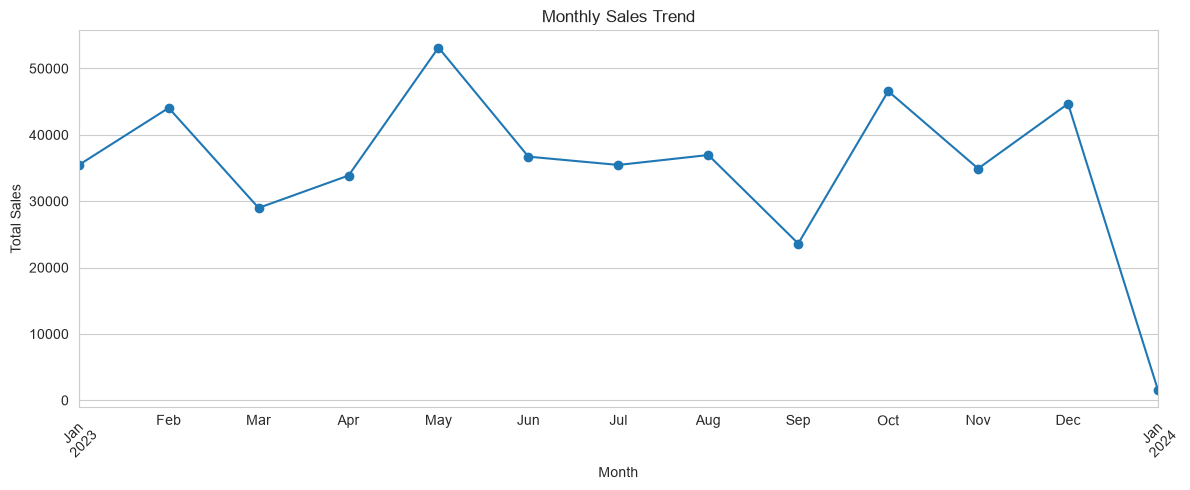

In [31]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Monthly Sales Trend — Observation

The monthly sales trend shows how total revenue changes over time. 
    The chart helps identify periods of higher and lower sales and can reveal potential seasonal patterns in customer purchasing behaviour.
    The month with the highest sales was MAY, while the month with the lowest sales was JAN2024.

In [32]:
df["Quarter"] = df["Date"].dt.to_period("Q")

In [33]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

In [34]:
quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

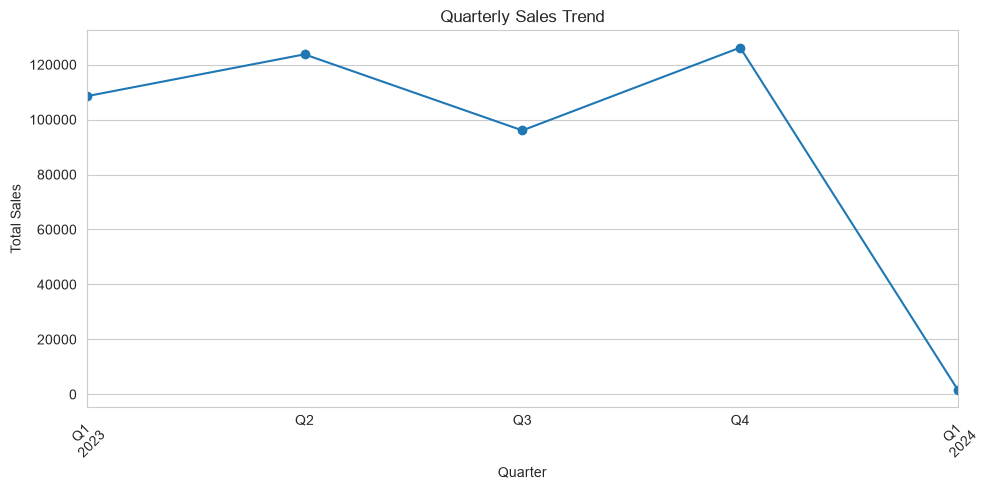

In [35]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Quarterly Sales Trend — Observation

The quarterly sales analysis provides a broader view of revenue performance.
    The highest-performing quarter was Q4, while the lowest-performing quarter was Q1 2024. 
        This pattern can help the business plan inventory, promotions, and marketing activities around periods of higher demand.

In [36]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [37]:
df[["Age", "Age Group"]].head()

,Age,Age Group
0,34,26-35
1,26,26-35
2,50,46-55
3,37,36-45
4,30,26-35


In [38]:
age_groups = df["Age Group"].value_counts().sort_index()

age_groups

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

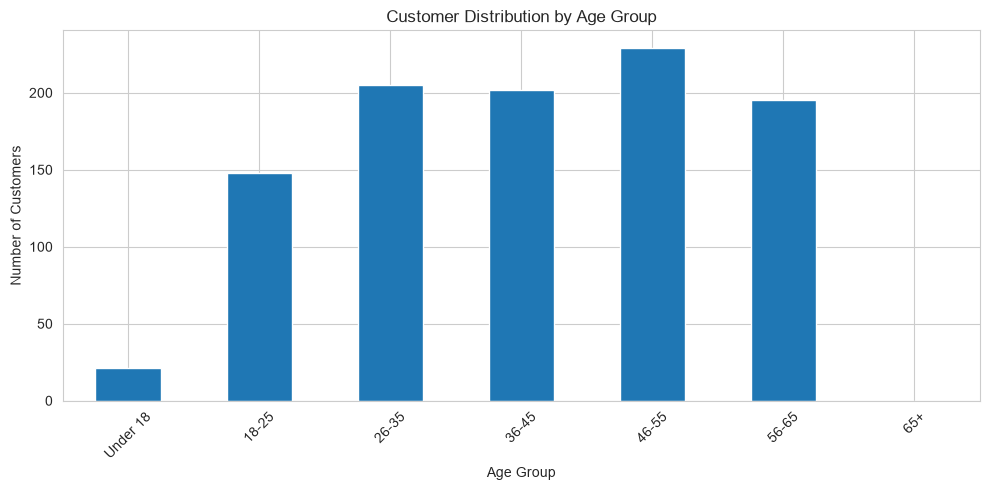

In [39]:
plt.figure(figsize=(10, 5))

age_groups.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Age Group Analysis — Observation

The age-group distribution shows the demographic composition of the customers.
    The largest customer segment is 46-55, indicating that this age group represents an important target market for the business.

In [40]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

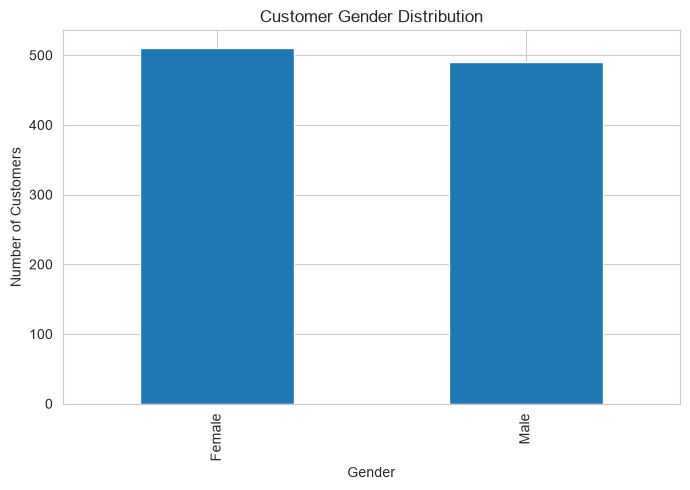

In [41]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind="bar")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

In [ ]:
### Gender Distribution — Observation

The gender distribution shows the proportion of customers by gender.
    The analysis indicates that FEMALE. customers represent the larger share of the dataset. 
        This information can help the business evaluate whether its current marketing and product strategies align with its customer demographics.

In [42]:
top_products = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

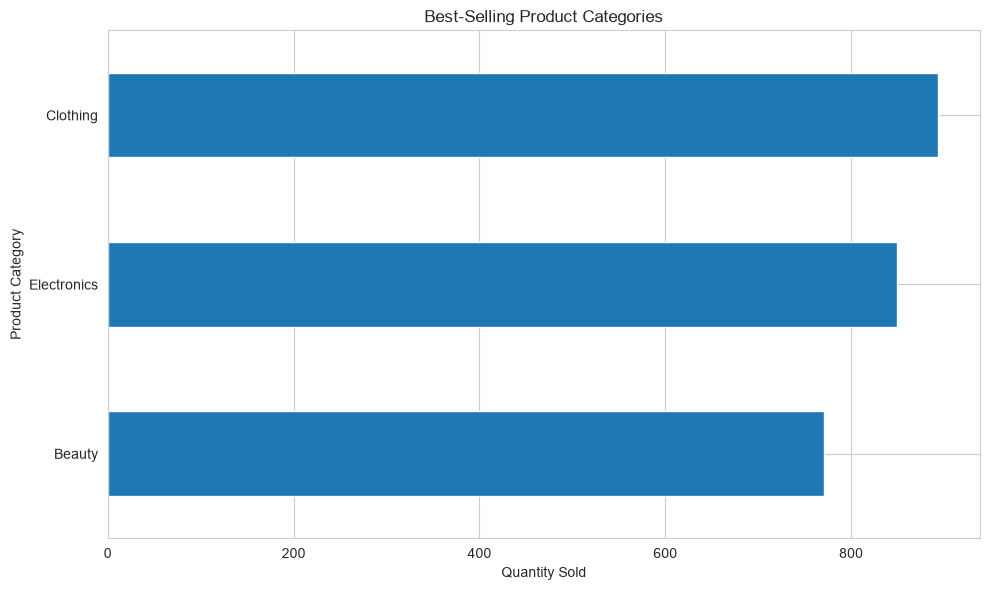

In [43]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Best-Selling Product Categories")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

In [ ]:
### Product Category Sales — Observation

The analysis identifies the product categories with the highest sales volume.
    The category with the highest quantity sold is CLOTHING. 
    These high-performing categories should receive appropriate inventory attention to ensure that customer demand can be met.

In [44]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

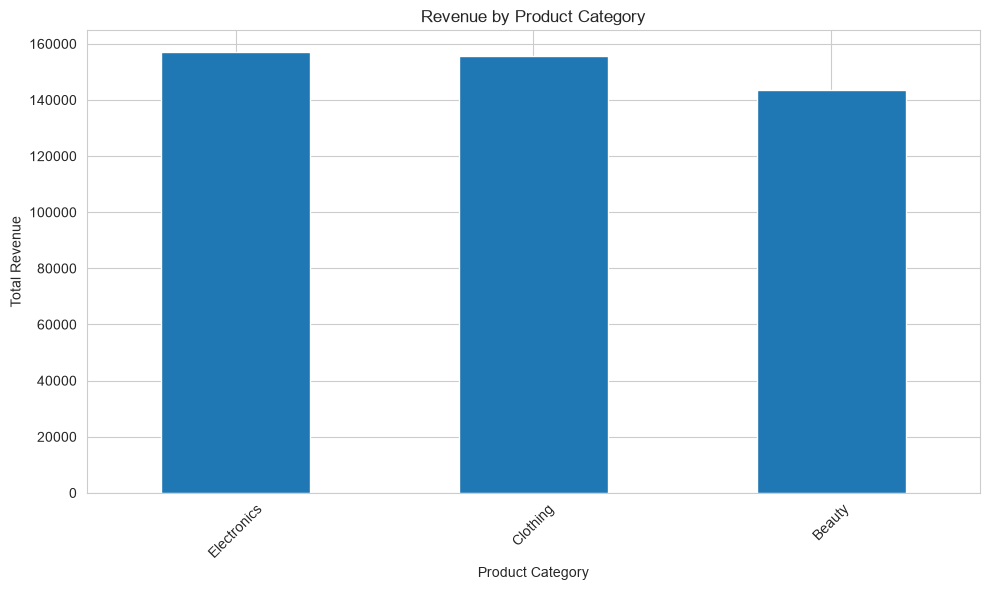

In [45]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Revenue by Product Category — Observation

The revenue analysis shows differences in financial performance across product categories. 
    The category generating the highest revenue is ELECTRONICS, while the category generating the lowest revenue is BEAUTY. 
    The business can use this information to prioritize high-revenue categories while investigating opportunities to improve weaker categories.

In [46]:
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


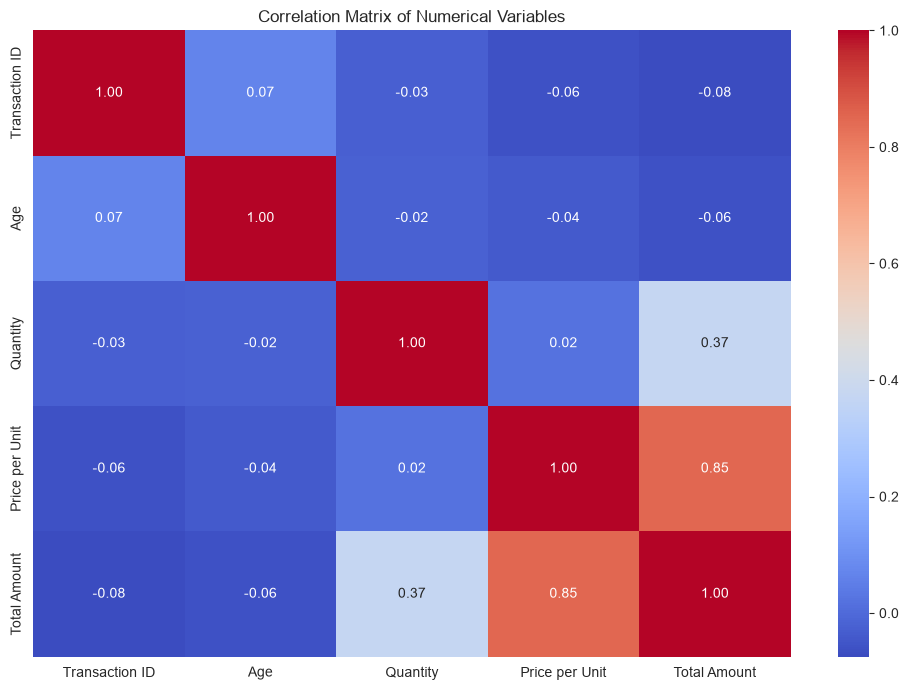

In [47]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()

In [ ]:
### Correlation Analysis — Observation

The correlation heatmap shows the relationships between the numerical variables.
    Variables with values closer to +1 have a strong positive relationship, while values closer to -1 indicate a strong negative relationship.
    The relationship between price per unit and total amount is particularly noticeable and may provide useful insight into purchasing behaviour and sales performance.

In [48]:
age_sales = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .mean()
    .sort_values(ascending=False)
)

age_sales

Age Group
Under 18    534.047619
18-25       495.506757
26-35       480.390244
36-45       454.801980
46-55       439.694323
56-65       412.358974
65+                NaN
Name: Total Amount, dtype: float64

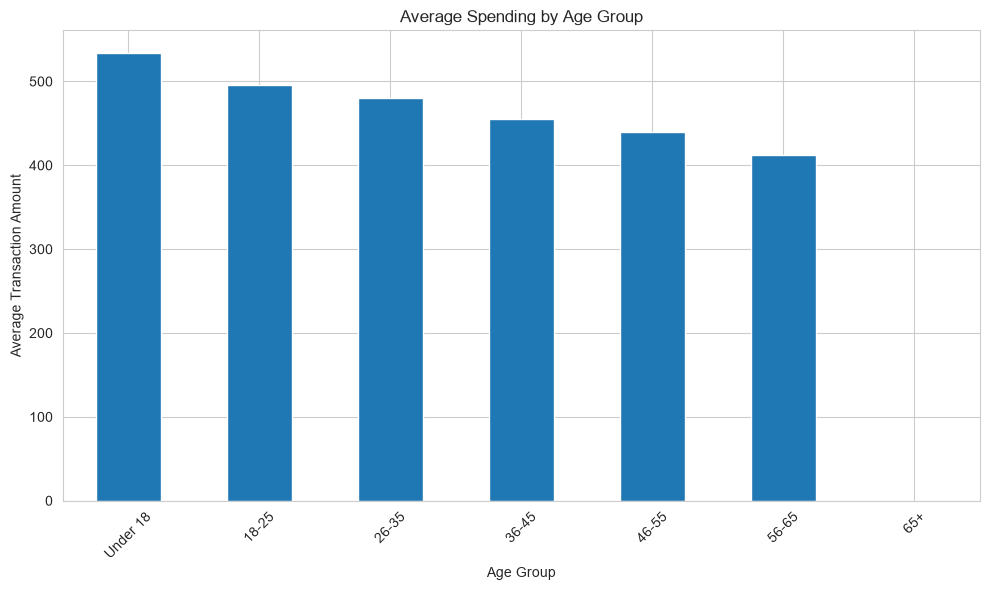

In [49]:
plt.figure(figsize=(10, 6))

age_sales.plot(kind="bar")

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Additional Insight — Average Spending by Age Group

The analysis reveals differences in average transaction value across customer age groups. 
    While the largest age group represents the highest number of customers, it may not necessarily have the highest average spending. 
    This distinction can help the business differentiate between customer segments based on both customer volume and purchasing value.

In [ ]:
#Key findings:-
1.highest-sales month
2.highest-sales quarter
3.largest age group
4.gender distribution
5.best-performing category
6.highest-revenue category
7.correlation findings
8.age group with highest average spending

#3 actionable recommendations:- 

Recommendation 1 — Inventory
If a category consistently generates high sales.
Maintain sufficient inventory for high-performing product categories to prevent stockouts.

Recommendation 2 — Targeted Marketing
If one age group dominates.
Develop targeted marketing campaigns for the largest customer segment.

Recommendation 3 — Seasonal Planning
If certain months have higher sales.
Increase inventory and promotional activity before high-sales periods.